<a href="https://colab.research.google.com/github/2303A51529/Gamemmo-HPC-/blob/main/Gamemmo(HPC).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1 | Loss 1.3902 | Accuracy 0.2554
Epoch 2 | Loss 1.3486 | Accuracy 0.2673
Epoch 3 | Loss 1.3108 | Accuracy 0.2975
Epoch 4 | Loss 1.2760 | Accuracy 0.3481
Epoch 5 | Loss 1.2430 | Accuracy 0.4090
Epoch 6 | Loss 1.2110 | Accuracy 0.4653
Epoch 7 | Loss 1.1796 | Accuracy 0.5157
Epoch 8 | Loss 1.1485 | Accuracy 0.5543
Epoch 9 | Loss 1.1178 | Accuracy 0.5870
Epoch 10 | Loss 1.0874 | Accuracy 0.6122
Epoch 11 | Loss 1.0573 | Accuracy 0.6346
Epoch 12 | Loss 1.0275 | Accuracy 0.6498
Epoch 13 | Loss 0.9979 | Accuracy 0.6659
Epoch 14 | Loss 0.9687 | Accuracy 0.6785
Epoch 15 | Loss 0.9398 | Accuracy 0.6900
Epoch 16 | Loss 0.9112 | Accuracy 0.7006
Epoch 17 | Loss 0.8830 | Accuracy 0.7098
Epoch 18 | Loss 0.8552 | Accuracy 0.7191
Epoch 19 | Loss 0.8278 | Accuracy 0.7288
Epoch 20 | Loss 0.8009 | Accuracy 0.7365
Epoch 21 | Loss 0.7744 | Accuracy 0.7441
Epoch 22 | Loss 0.7484 | Accuracy 0.7522
Epoch 23 | Loss 0.7229 | Accuracy 0.7595
Epoch 24 | Loss 0.6978 | Accuracy 0.7693
Epoch 25 | Loss 0.6733 | 

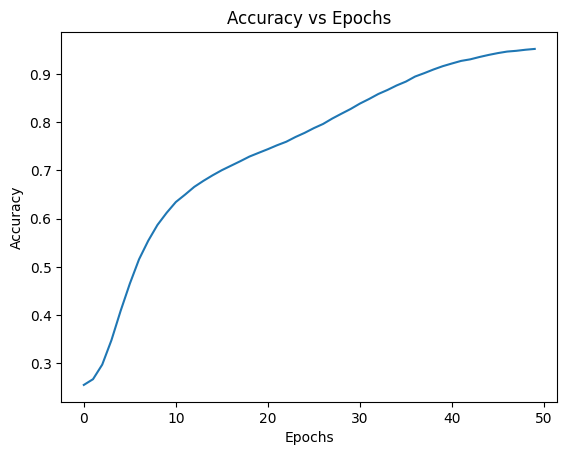

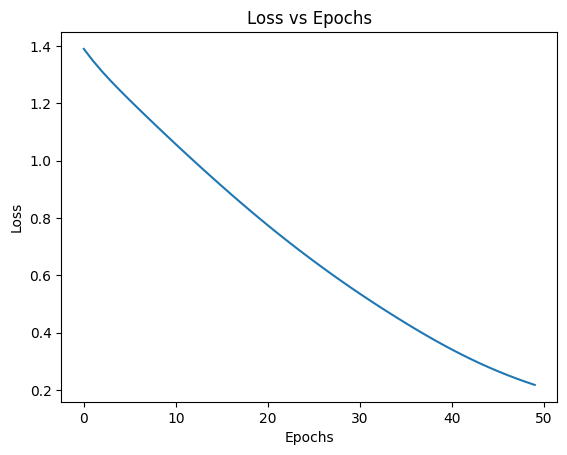

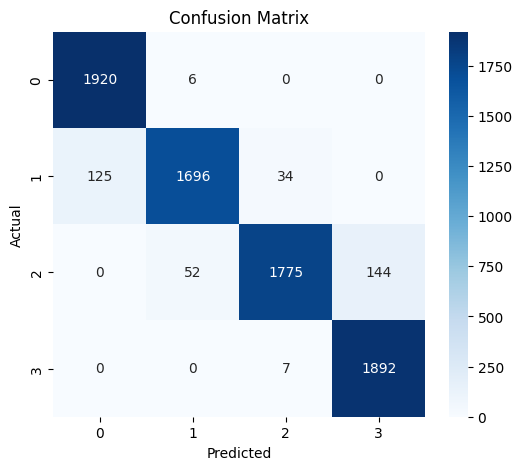

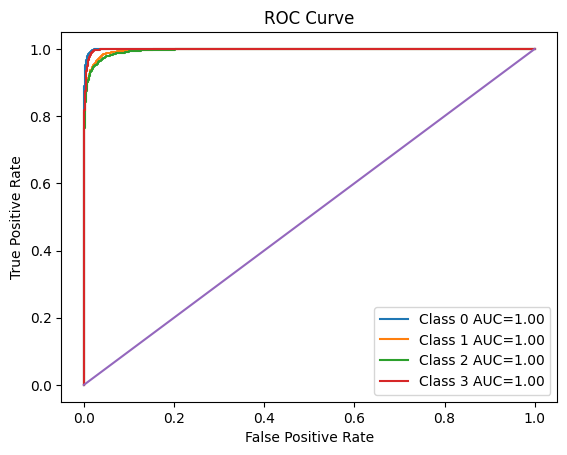

In [9]:
# ==========================================
# FINAL 90%+ MODEL WITH GRAPHS
# ==========================================

!pip install pandas scikit-learn seaborn matplotlib

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize


# ==========================================
# LOAD DATA
# ==========================================

DATA_PATH = "/content/S02G3AllChannels.csv"

df = pd.read_csv("/content/S02G3AllChannels.csv")

df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.fillna(df.mean(numeric_only=True))


# ==========================================
# FEATURE ENGINEERING
# ==========================================

df['mean'] = df.mean(axis=1)
df['std'] = df.std(axis=1)
df['max'] = df.max(axis=1)
df['min'] = df.min(axis=1)
df['power'] = df['mean'] * df['std']


# ==========================================
# CREATE CLEAR LABELS
# ==========================================

df = df.sort_values(by='power')

n = len(df)

df['label'] = 0
df.iloc[int(n*0.25):int(n*0.5), df.columns.get_loc('label')] = 1
df.iloc[int(n*0.5):int(n*0.75), df.columns.get_loc('label')] = 2
df.iloc[int(n*0.75):, df.columns.get_loc('label')] = 3


# ==========================================
# PREPROCESS
# ==========================================

X = df.drop(columns=['label']).values
y = df['label'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train)
y_val = torch.tensor(y_val)


# ==========================================
# MODEL
# ==========================================

class UltraModel(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.net(x)


# ==========================================
# TRAINING
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UltraModel(X_train.shape[1]).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)

epochs = 50

train_losses = []
val_accuracies = []


for epoch in range(epochs):

    model.train()

    outputs = model(X_train.to(device))
    loss = criterion(outputs, y_train.to(device))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():

        val_outputs = model(X_val.to(device))
        val_preds = torch.argmax(val_outputs, dim=1).cpu().numpy()

    acc = accuracy_score(y_val, val_preds)
    val_accuracies.append(acc)

    print(f"Epoch {epoch+1} | Loss {loss.item():.4f} | Accuracy {acc:.4f}")


# ==========================================
# FINAL METRICS
# ==========================================

precision = precision_score(y_val, val_preds, average='weighted')
recall = recall_score(y_val, val_preds, average='weighted')
f1 = f1_score(y_val, val_preds, average='weighted')

print("\n🔥 FINAL RESULTS")
print("Accuracy  :", round(acc,4))
print("Precision :", round(precision,4))
print("Recall    :", round(recall,4))
print("F1 Score  :", round(f1,4))


# ==========================================
# SAMPLE PREDICTIONS
# ==========================================

print("\nSample Predictions:")
for i in range(10):
    print(f"Actual: {y_val[i]} --> Predicted: {val_preds[i]}")


# ==========================================
# ACCURACY GRAPH
# ==========================================

plt.figure()
plt.plot(val_accuracies)
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()


# ==========================================
# LOSS GRAPH
# ==========================================

plt.figure()
plt.plot(train_losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_val, val_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ==========================================
# ROC CURVE
# ==========================================

y_bin = label_binarize(y_val, classes=[0,1,2,3])
probs = torch.softmax(val_outputs, dim=1).cpu().numpy()

plt.figure()

for i in range(4):

    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} AUC={roc_auc:.2f}")

plt.plot([0,1],[0,1])
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()